# Customer Churn Prediction using Logistic Regression

## Project Objective
The goal of this project is to predict whether a telecom customer is likely to churn or not using Logistic Regression.

Customer churn prediction is important because it helps businesses identify customers who may leave their services. With this information, companies can take actions to improve customer retention.

In this project, we will:
- explore the dataset
- clean and preprocess the data
- perform exploratory data analysis
- build a Logistic Regression model
- evaluate model performance
- interpret the key factors affecting churn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

## 1. Load the Dataset
In this step, we load the Telco Customer Churn dataset and view the first few rows.

In [3]:
df = pd.read_csv("D:/DSML/customer-churn-logistic-regression/data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Dataset Overview
We check the shape, column names, data types, and summary statistics of the dataset.

In [4]:
print("Shape of dataset:", df.shape)

Shape of dataset: (7043, 21)


In [5]:
print("Columns:")
print(df.columns.tolist())

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## 3. Check Missing Values
We inspect whether the dataset contains missing or problematic values.

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
print("Blank strings in TotalCharges:", (df["TotalCharges"] == " ").sum())

Blank strings in TotalCharges: 11


## 4. Data Cleaning
The `TotalCharges` column contains blank values stored as spaces.  
We replace them with `NaN`, convert the column to numeric format, and then remove missing rows.

We also drop `customerID` because it is only an identifier and does not help prediction.

In [11]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [12]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df = df.dropna().copy()
print("Shape after dropping missing rows:", df.shape)

Shape after dropping missing rows: (7032, 21)


In [14]:
df = df.drop("customerID", axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

## 5. Exploratory Data Analysis (EDA)
In this section, we explore the target variable and analyze how customer churn changes across different features.

### 5.1 Distribution of Target Variable
We first examine the distribution of the target variable `Churn`.

In [16]:
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


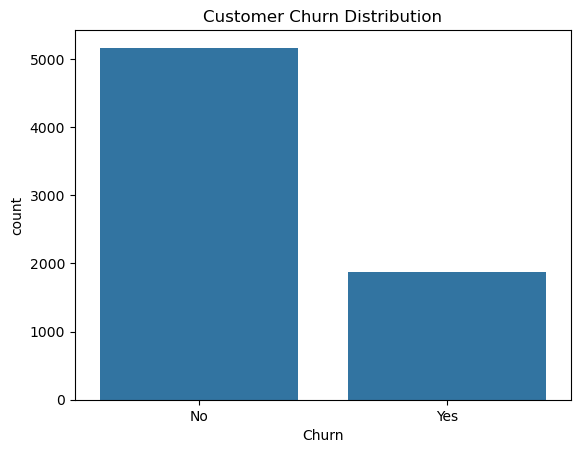

In [17]:
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")

plt.savefig("D:/DSML/customer-churn-logistic-regression/images/customer_churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.2 Categorical Feature Analysis
We explore churn patterns across important categorical variables such as gender, senior citizen status, partner, dependents, contract type, internet service, and payment method.

In [18]:
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


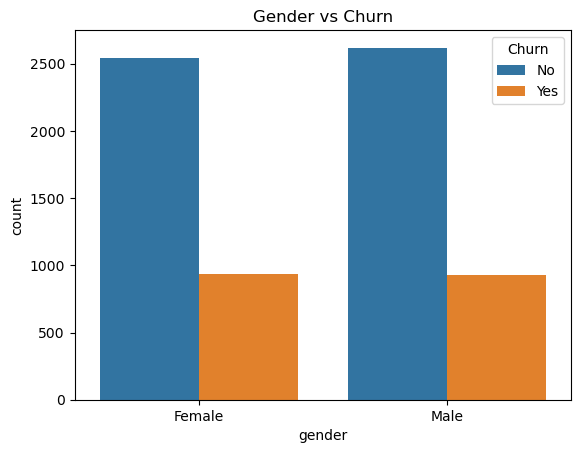

In [19]:
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Gender vs Churn")

plt.savefig("D:/DSML/customer-churn-logistic-regression/images/gender_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
pd.crosstab(df["SeniorCitizen"], df["Churn"])

Churn,No,Yes
SeniorCitizen,,
0,4497,1393
1,666,476


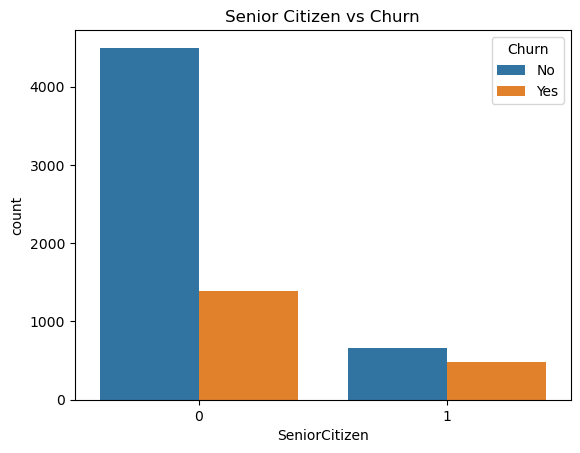

In [21]:
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)
plt.title("Senior Citizen vs Churn")

plt.savefig("D:/DSML/customer-churn-logistic-regression/images/senior_citizen_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
pd.crosstab(df["Partner"], df["Churn"])

Churn,No,Yes
Partner,,
No,2439,1200
Yes,2724,669


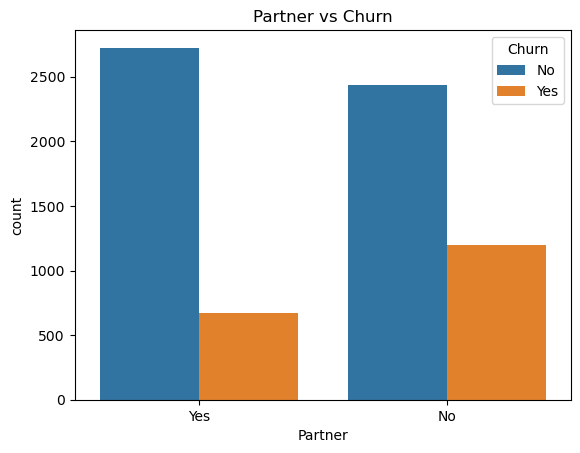

In [23]:
sns.countplot(x="Partner", hue="Churn", data=df)
plt.title("Partner vs Churn")

plt.savefig("D:/DSML/customer-churn-logistic-regression/images/partner_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
pd.crosstab(df["Dependents"], df["Churn"])

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1773,326


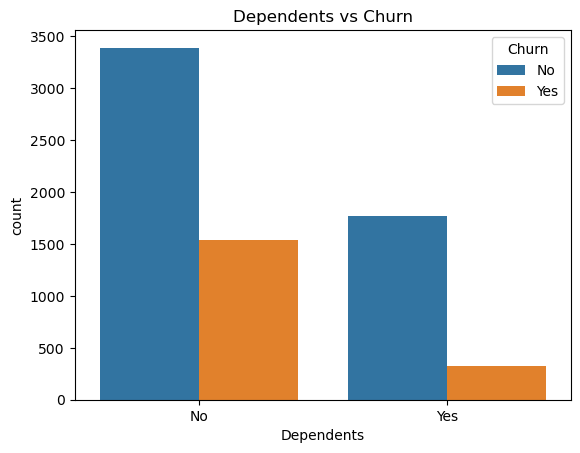

In [25]:
sns.countplot(x="Dependents", hue="Churn", data=df)
plt.title("Dependents vs Churn")

plt.savefig("D:/DSML/customer-churn-logistic-regression/images/dependents_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


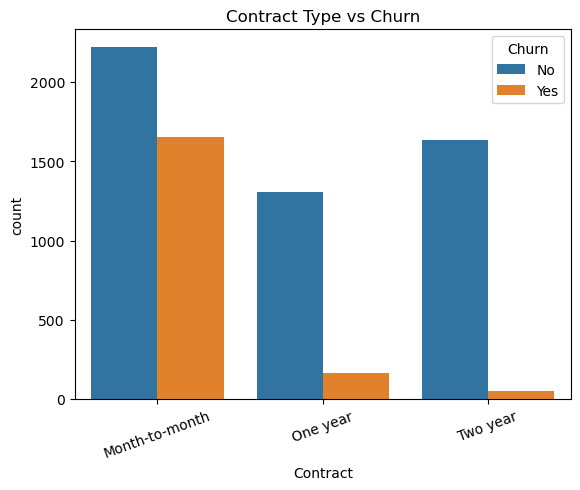

In [27]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.savefig("D:/DSML/customer-churn-logistic-regression/images/contract_type_vs_churn.png", dpi=300, bbox_inches="tight")
plt.xticks(rotation=20)
plt.show()

In [28]:
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


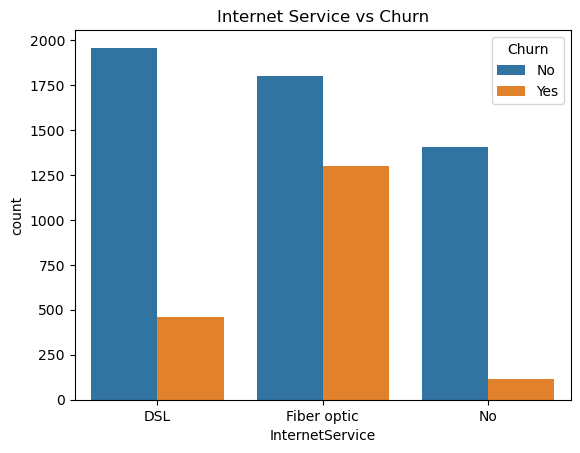

In [29]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Internet Service vs Churn")

plt.savefig("D:/DSML/customer-churn-logistic-regression/images/internet_service_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
pd.crosstab(df["PaymentMethod"], df["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


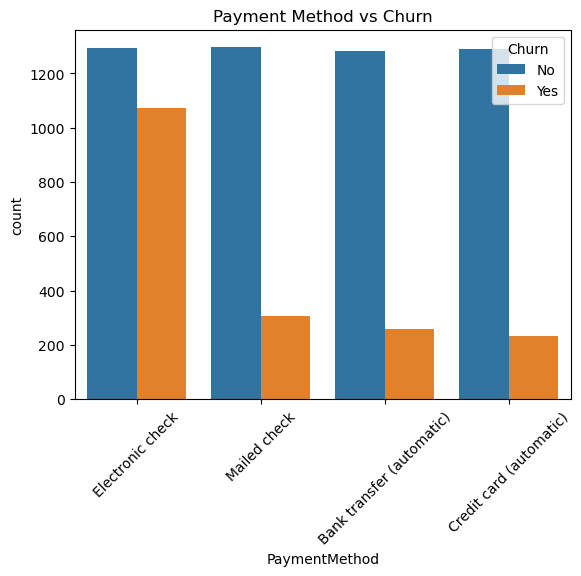

In [31]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)

plt.savefig("D:/DSML/customer-churn-logistic-regression/images/payment_method_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

### 5.3 Numerical Feature Analysis
We now analyze the distribution of numerical variables such as tenure, monthly charges, and total charges, and compare them with churn status.

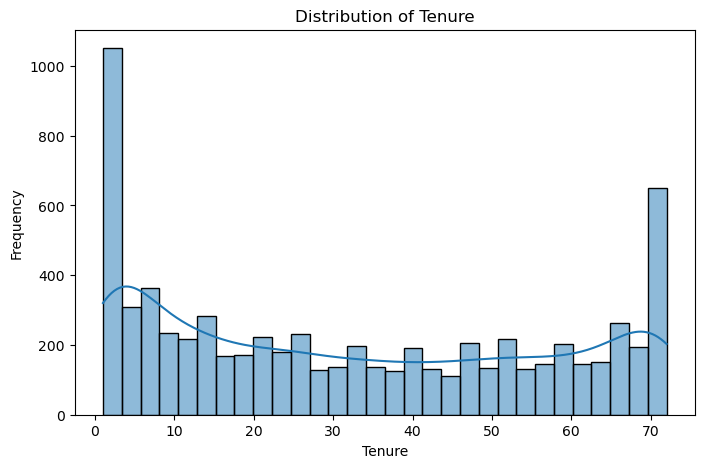

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Distribution of Tenure")
plt.xlabel("Tenure")
plt.ylabel("Frequency")

plt.savefig("D:/DSML/customer-churn-logistic-regression/images/distribution_of_tenure.png", dpi=300, bbox_inches="tight")
plt.show()

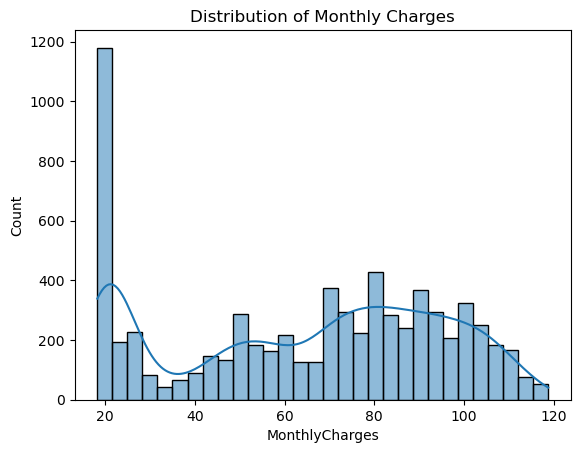

In [33]:
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.savefig(r"D:\DSML\customer-churn-logistic-regression\images\distribution_of_monthly_charges.png", dpi=300, bbox_inches="tight")
plt.show()

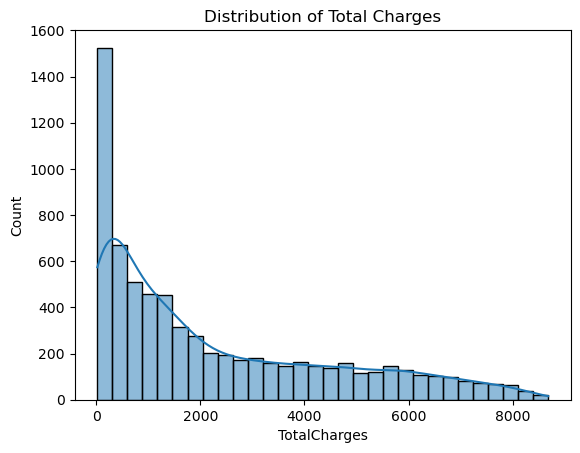

In [34]:
sns.histplot(df["TotalCharges"], bins=30, kde=True)
plt.title("Distribution of Total Charges")

plt.savefig("D:/DSML/customer-churn-logistic-regression/images/distribution_of_total_charges.png", dpi=300, bbox_inches="tight")
plt.show()

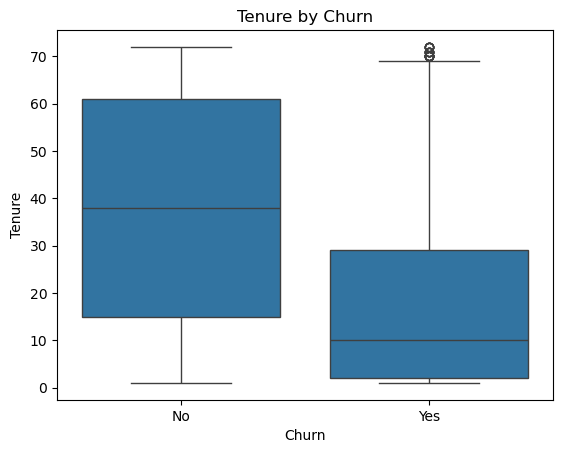

In [35]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.savefig("D:/DSML/customer-churn-logistic-regression/images/tenure_by_churn.png", dpi=300, bbox_inches="tight")
plt.show()

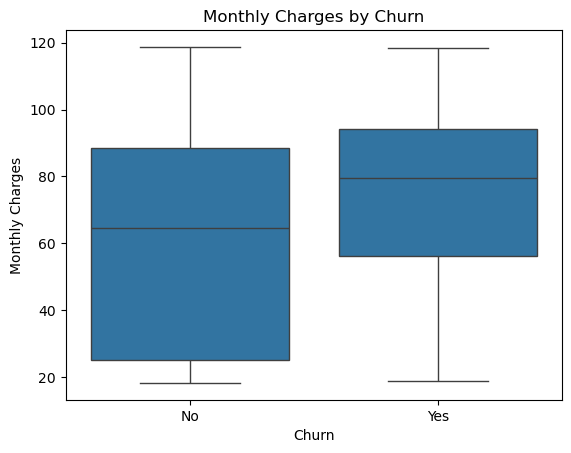

In [36]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.savefig("D:/DSML/customer-churn-logistic-regression/images/monthly_charges_by_churn.png", dpi=300, bbox_inches="tight")
plt.show()

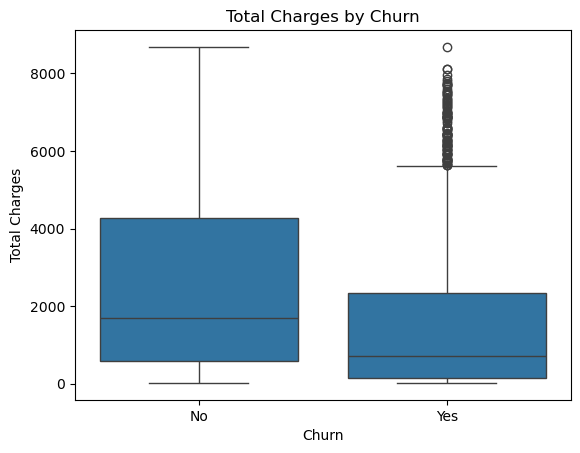

In [37]:
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.title("Total Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.savefig("D:/DSML/customer-churn-logistic-regression/images/total_charges_by_churn.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Data Preprocessing
Before training the model, we convert the target variable into binary format and encode categorical features.

In [38]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [39]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [40]:
print("Encoded dataset shape:", df_encoded.shape)

Encoded dataset shape: (7032, 31)


## 7. Define Features and Target
We separate the independent variables (`X`) and the target variable (`y`).

In [41]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [42]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 30)
y shape: (7032,)


## 8. Train-Test Split
We split the dataset into training and testing sets.  
The training set is used to train the model, and the testing set is used to evaluate its performance.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [44]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 30)
X_test shape: (1407, 30)
y_train shape: (5625,)
y_test shape: (1407,)


## 9. Feature Scaling
Logistic Regression performs better when numerical features are scaled.  
So, we standardize the training and testing data.

In [45]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 10. Build and Train the Logistic Regression Model
We now train a Logistic Regression model using the scaled training data.

In [46]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

## 11. Make Predictions
We use the trained model to predict customer churn on the test data.

In [47]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

## 12. Model Evaluation
We evaluate the model using:
- Accuracy
- Confusion Matrix
- Classification Report
- ROC-AUC Score
- ROC Curve

In [48]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.8038


In [49]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[916, 117],
       [159, 215]])

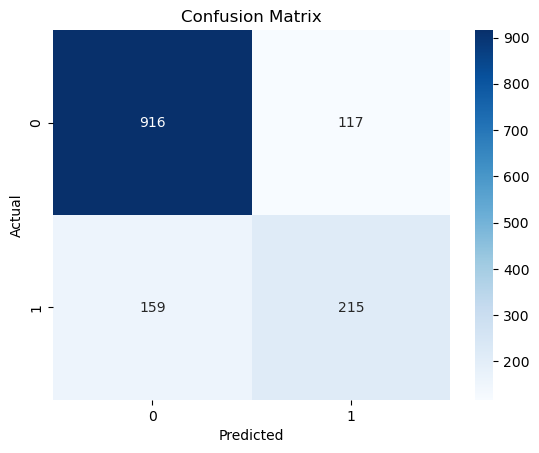

In [50]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("D:/DSML/customer-churn-logistic-regression/images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [52]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.8357


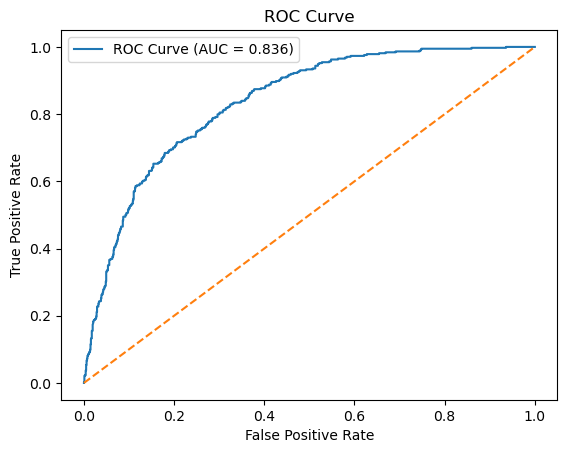

In [53]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("D:/DSML/customer-churn-logistic-regression/images/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Feature Importance Interpretation
In Logistic Regression, the model coefficients help us understand which features increase or decrease the likelihood of churn.

In [54]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)
coefficients.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,0.727745
3,TotalCharges,0.639028
21,StreamingTV_Yes,0.249702
23,StreamingMovies_Yes,0.236368
9,MultipleLines_Yes,0.214359
28,PaymentMethod_Electronic check,0.181473
26,PaperlessBilling_Yes,0.142663
0,SeniorCitizen,0.070792
17,DeviceProtection_Yes,0.068965
29,PaymentMethod_Mailed check,0.033392


In [55]:
coefficients.tail(10)

,Feature,Coefficient
18,TechSupport_No internet service,-0.088138
16,DeviceProtection_No internet service,-0.088138
22,StreamingMovies_No internet service,-0.088138
6,Dependents_Yes,-0.105956
19,TechSupport_Yes,-0.118240
13,OnlineSecurity_Yes,-0.136804
24,Contract_One year,-0.310898
25,Contract_Two year,-0.602591
2,MonthlyCharges,-0.851551
1,tenure,-1.347613


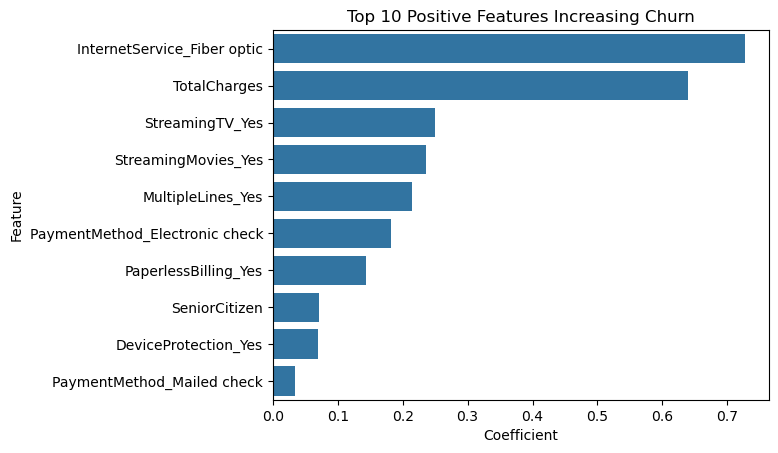

In [56]:
top_positive = coefficients.head(10)

sns.barplot(x="Coefficient", y="Feature", data=top_positive)
plt.title("Top 10 Positive Features Increasing Churn")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.savefig("D:/DSML/customer-churn-logistic-regression/images/top_10_positive_features_increasing_churn.png", dpi=300, bbox_inches="tight")
plt.show()

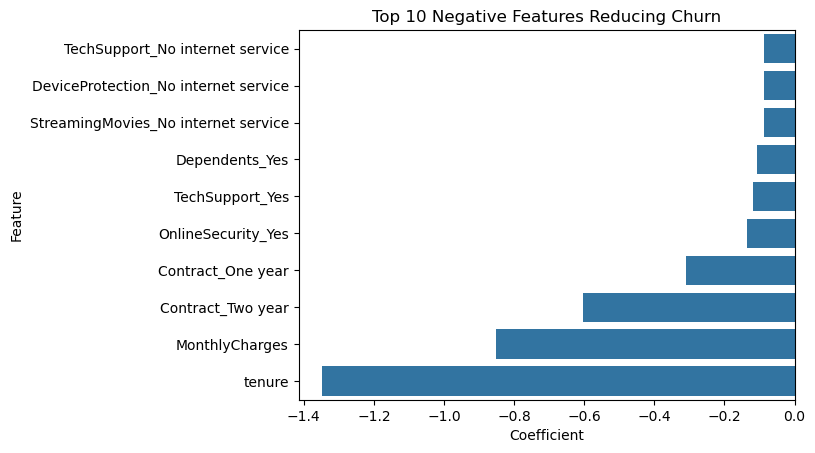

In [57]:
top_negative = coefficients.tail(10)

sns.barplot(x="Coefficient", y="Feature", data=top_negative)
plt.title("Top 10 Negative Features Reducing Churn")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.savefig("D:/DSML/customer-churn-logistic-regression/images/top_10_negative_features_reducing_churn.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Business Insights
Here we calculate churn percentages across important business-related categories.

In [58]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [59]:
internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
internet_churn

Churn,0,1
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


In [60]:
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
payment_churn

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


## 15. Conclusion
This project developed a Logistic Regression model to predict customer churn using the Telco Customer Churn dataset.

Main steps completed in this project:
- loaded and explored the dataset
- handled blank values in `TotalCharges`
- dropped the `customerID` column
- encoded categorical variables
- scaled the data
- trained a Logistic Regression model
- evaluated performance using multiple classification metrics

The analysis also helped identify important factors related to churn, such as contract type, tenure, and monthly charges.

## 16. Future Improvements
Possible improvements for this project:
- try Decision Tree and Random Forest models
- perform hyperparameter tuning
- use cross-validation
- address class imbalance more carefully
- add more feature engineering